Step 3: Stable Diffusion img2img baseline — and deliberately breaking it.

*   List item
*   List item

Cell 1 — setup, hardcoded DesignPlan (your real latest output):

In [ ]:
from pydantic import BaseModel

class FurnitureItem(BaseModel):
    item: str
    description: str
    action: str

class DesignPlan(BaseModel):
    design_style: str
    color_palette: list[str]
    furniture_changes: list[FurnitureItem]
    layout_changes: list[str]
    generation_prompt: str

design = DesignPlan(
    design_style="Modern Minimalist",
    color_palette=["Beige", "White", "Light Wood"],
    furniture_changes=[
        FurnitureItem(item="Bed Frame", description="Low-profile light wood platform bed with clean lines.", action="replace"),
        FurnitureItem(item="Nightstand", description="Sleek light wood or white floating nightstand with hidden storage.", action="replace"),
        FurnitureItem(item="Right Nightstand", description="Matching light wood floating nightstand for visual balance on the right side of the bed.", action="add"),
        FurnitureItem(item="Table", description="Minimalist white writing desk with light wood legs.", action="replace"),
        FurnitureItem(item="Wooden Wardrobe", description="Modern white wardrobe with light wood trim and handleless doors.", action="replace"),
    ],
    layout_changes=[
        "Center the bed frame on the primary wall to fit matching nightstands on both left and right sides.",
        "Place the minimalist desk in a corner near natural light to keep the central room flow open."
    ],
    generation_prompt="A modern minimalist bedroom featuring soft beige walls and light oak floors. A low-profile light wood platform bed with crisp white bedding is centered on the wall, flanked by two matching light wood floating nightstands topped with modern slim table lamps. A sleek white wardrobe and simple light wood desk sit cleanly against adjacent walls. Bright, airy, uncluttered aesthetic, natural light, high-end interior photography, 8k resolution."
)

print(design.generation_prompt)

A modern minimalist bedroom featuring soft beige walls and light oak floors. A low-profile light wood platform bed with crisp white bedding is centered on the wall, flanked by two matching light wood floating nightstands topped with modern slim table lamps. A sleek white wardrobe and simple light wood desk sit cleanly against adjacent walls. Bright, airy, uncluttered aesthetic, natural light, high-end interior photography, 8k resolution.


Cell 2 — install:

In [ ]:
!pip install -U diffusers transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 14.4 MB/s eta 0:00:00


Cell 3 — torchaudio fix + load SD pipeline:

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("torch version:", torch.__version__)

CUDA available: True
torch version: 2.11.0+cu128


In [ ]:
import sys
import types
import importlib.machinery

fake_torchaudio = types.ModuleType("torchaudio")
fake_torchaudio.__spec__ = importlib.machinery.ModuleSpec("torchaudio", loader=None)
sys.modules["torchaudio"] = fake_torchaudio

import torch
from diffusers import StableDiffusionImg2ImgPipeline

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

print("SD pipeline loaded")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

SD pipeline loaded


Cell 4 — upload the same bedroom photo:

Saving room1.jpg to room1 (1).jpg
Loaded: room1 (1).jpg


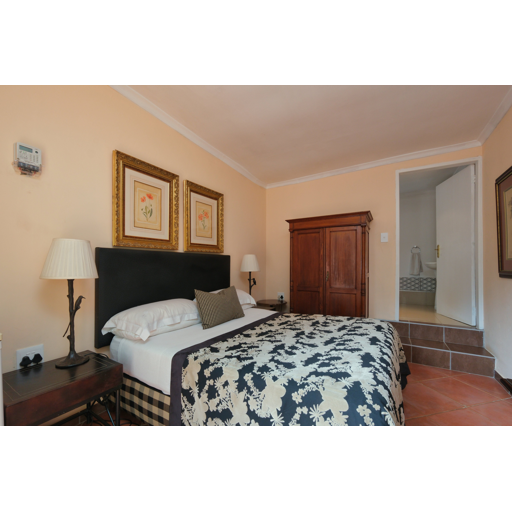

In [ ]:
from google.colab import files
import io
from PIL import Image

def resize_with_padding(image: Image.Image, target_size: int = 512) -> Image.Image:
    ratio = min(target_size / image.width, target_size / image.height)
    new_size = (int(image.width * ratio), int(image.height * ratio))
    resized = image.resize(new_size)

    padded = Image.new("RGB", (target_size, target_size), (255, 255, 255))
    offset = ((target_size - new_size[0]) // 2, (target_size - new_size[1]) // 2)
    padded.paste(resized, offset)
    return padded

uploaded = files.upload()
filename = list(uploaded.keys())[0]
init_image = resize_with_padding(
    Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
)

print(f"Loaded: {filename}")
init_image

Cell 5 — run img2img:

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', high - end interior photography , 8 k resolution .']


  0%|          | 0/37 [00:00<?, ?it/s]

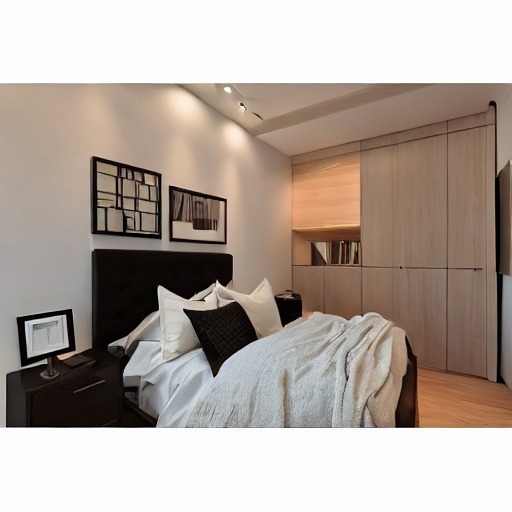

In [ ]:
result_image = pipe(
    prompt=design.generation_prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]

result_image

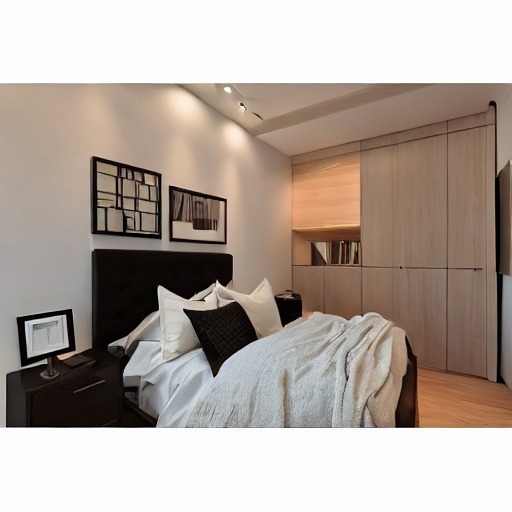

In [ ]:
result_image.save("output.png")
result_image